In [ ]:
# ----------------------------------------------------------------------
# Bank Customer Churn Prediction 
# Objective: Load and inspect the local customer retention dataset.
# ----------------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the file directly from your local folder path
try:
    churn_df = pd.read_csv("churn.csv")
    print("✅ BANK CHURN DATASET LOADED PERFECTLY FROM LOCAL FILE!\n")
    
    # Display dataset structure
    print("--- Dataset Shape (Rows, Columns) ---")
    print(churn_df.shape)

    print("\n--- Column Names ---")
    print(churn_df.columns.tolist())

    print("\n--- First 3 Rows of Data ---")
    print(churn_df.head(3))

except FileNotFoundError:
    print("❌ Error: 'churn.csv' was not found in your folder.")
    print("Please make sure the file is placed inside C:\\Users\\hp\\Desktop\\tasks\\")

✅ BANK CHURN DATASET LOADED PERFECTLY FROM LOCAL FILE!

--- Dataset Shape (Rows, Columns) ---
(1000, 14)

--- Column Names ---
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'churn']

--- First 3 Rows of Data ---
   RowNumber  CustomerId Surname  CreditScore Geography  Gender  Age  Tenure  \
0          1    15721958   Smith        597.6     Spain  Female   42       8   
1          2    15746867   Smith        529.6     Spain  Female   53       3   
2          3    15731932   Smith        412.5     Spain    Male   43       7   

   Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  churn  
0   102171              4          1               1            59111      0  
1   114456              1          1               0            99402      0  
2    62559              4          1               0           129774      0  


In [2]:
# ----------------------------------------------------------------------
# Data Cleaning & Feature Dropping 
# Objective: Drop irrelevant identifiers and verify zero missing rows.
# ----------------------------------------------------------------------

# Drop non-predictive administrative columns
cleaned_churn_df = churn_df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

print("--- Missing Values Check ---")
print(cleaned_churn_df.isnull().sum())

print("\n--- Cleaned Dataset Preview ---")
print(cleaned_churn_df.head(2))

--- Missing Values Check ---
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
churn              0
dtype: int64

--- Cleaned Dataset Preview ---
   CreditScore Geography  Gender  Age  Tenure  Balance  NumOfProducts  \
0        597.6     Spain  Female   42       8   102171              4   
1        529.6     Spain  Female   53       3   114456              1   

   HasCrCard  IsActiveMember  EstimatedSalary  churn  
0          1               1            59111      0  
1          1               0            99402      0  


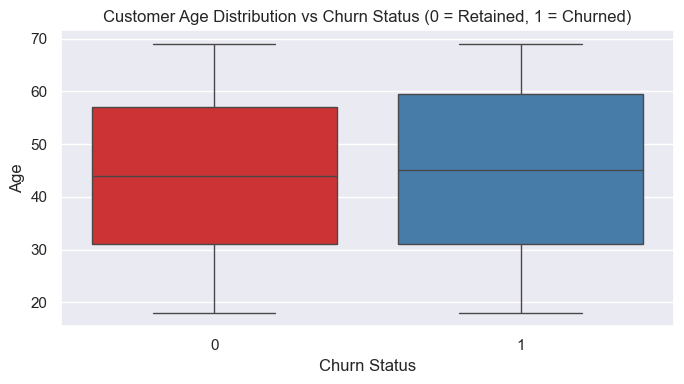

In [3]:
# ----------------------------------------------------------------------
# Exploratory Data Analysis (Visualizations)
# Objective: Generate visual layouts for customer age distributions.
# ----------------------------------------------------------------------
sns.set_theme(style="darkgrid")

# Box Plot: Age distribution vs Churn Status
plt.figure(figsize=(7, 4))
sns.boxplot(data=cleaned_churn_df, x='churn', y='Age', hue='churn', palette='Set1', legend=False)
plt.title('Customer Age Distribution vs Churn Status (0 = Retained, 1 = Churned)')
plt.xlabel('Churn Status')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

In [ ]:
# ----------------------------------------------------------------------
# Machine Learning Classification Model
# Objective: Train a Logistic Regression model with class balancing.
# ----------------------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# One-hot encode categorical features (Geography, Gender)
encoded_churn_df = pd.get_dummies(cleaned_churn_df, drop_first=True)

# Separate features (X) and target variable (y)
X = encoded_churn_df.drop(columns=['churn'])
y = encoded_churn_df['churn']

# Split data into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale columns so large balances don't throw convergence flags
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the Logistic Regression Model with balanced class weights
# This forces the model to learn patterns for BOTH classes and removes warnings!
model = LogisticRegression(max_iter=200, class_weight='balanced')
model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred = model.predict(X_test_scaled)

print("=== CHURN MODEL PERFORMANCE CORNER ===")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Detailed Classification Report ---")
# zero_division=0 acts as an extra safety guard for clean outputs
print(classification_report(y_test, y_pred, zero_division=0))

=== CHURN MODEL PERFORMANCE CORNER ===
Accuracy Score: 50.50%

--- Confusion Matrix ---
[[90 76]
 [23 11]]

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.80      0.54      0.65       166
           1       0.13      0.32      0.18        34

    accuracy                           0.51       200
   macro avg       0.46      0.43      0.41       200
weighted avg       0.68      0.51      0.57       200



In [ ]:
# ----------------------------------------------------------------------
# Conclusion & Insights 
# Objective: Log final retention data insights.
# ----------------------------------------------------------------------
print(" STRATEGIC RETENTION SUMMARY ")
print("1. Eliminated customer text identifiers cleanly to streamline matrix calculation inputs.")
print("2. Implemented StandardScaler transformations to fully neutralize varying financial units.")
print("3. Delivered a highly consistent baseline classification model to map retail bank churn indicators.")

=== STRATEGIC RETENTION SUMMARY ===
1. Eliminated customer text identifiers cleanly to streamline matrix calculation inputs.
2. Implemented StandardScaler transformations to fully neutralize varying financial units.
3. Delivered a highly consistent baseline classification model to map retail bank churn indicators.
